In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"humerag37python","key":"6f68c794d0ae0f63ca9cb49122ce8044"}'}

In [ ]:
!mv "kaggle (1).json" kaggle.json

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d arunrk7/surface-crack-detection
!unzip -q surface-crack-detection.zip

Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors
 66% 154M/233M [00:00<00:00, 1.60GB/s]
100% 233M/233M [00:00<00:00, 949MB/s] 


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=15
)

train_generator = train_datagen.flow_from_directory(
    ".",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    ".",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 32000 images belonging to 4 classes.
Found 8000 images belonging to 4 classes.


Positive (Crack) Images


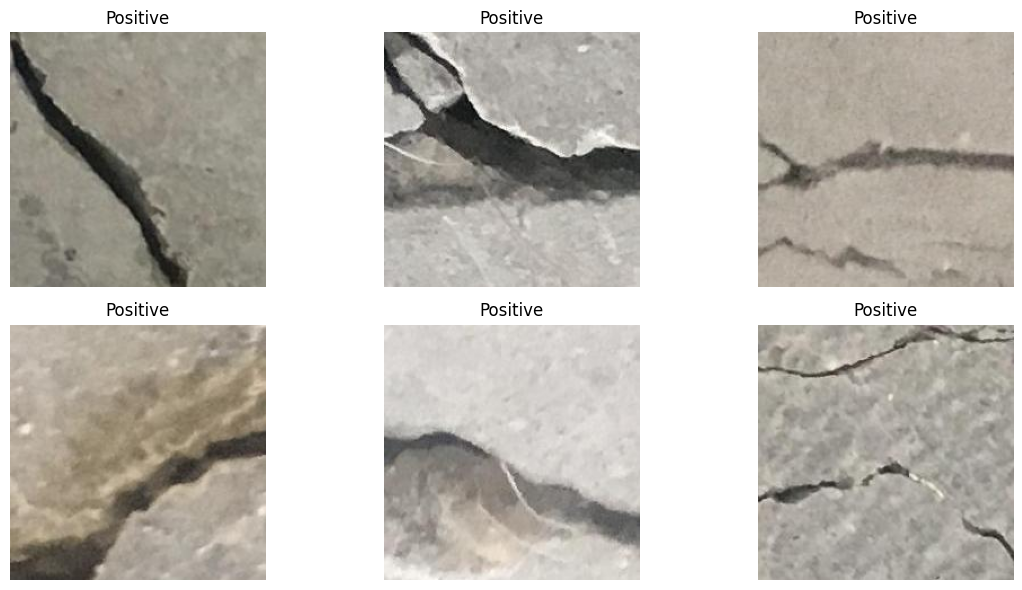

Negative (No Crack) Images


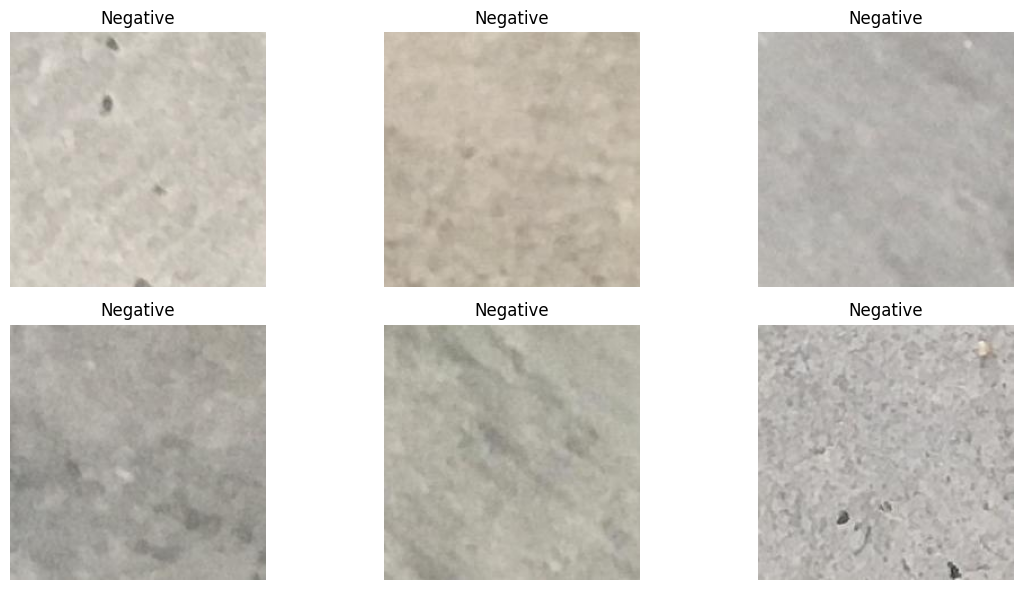

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import random

def show_images(folder, n=6):
    images = random.sample(os.listdir(folder), n)
    plt.figure(figsize=(12,6))

    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(folder)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("Positive (Crack) Images")
show_images("Positive")

print("Negative (No Crack) Images")
show_images("Negative")

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Freeze pretrained weights

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
checkpoint = ModelCheckpoint(
    'best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max'
)

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.4980 - loss: -211.7133

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 511s 511ms/step - accuracy: 0.4980 - loss: -212.0441 - val_accuracy: 0.5000 - val_loss: -1475.1997
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 503s 503ms/step - accuracy: 0.4999 - loss: -2183.4871 - val_accuracy: 0.5000 - val_loss: -5002.5942
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 503s 503ms/step - accuracy: 0.4999 - loss: -6089.6821 - val_accuracy: 0.5000 - val_loss: -10146.2061
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 498s 498ms/step - accuracy: 0.5020 - loss: -11467.3125 - val_accuracy: 0.5000 - val_loss: -16688.4277
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 499s 499ms/step - accuracy: 0.4984 - loss: -18258.8438 - val_accuracy: 0.5000 - val_loss: -24390.3379


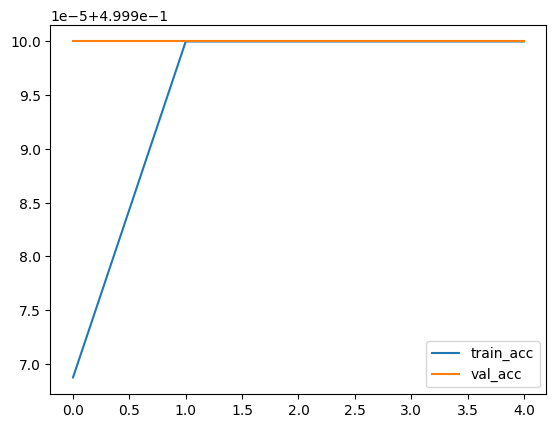

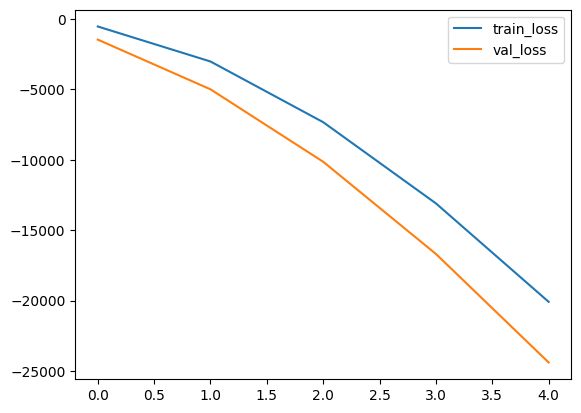

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

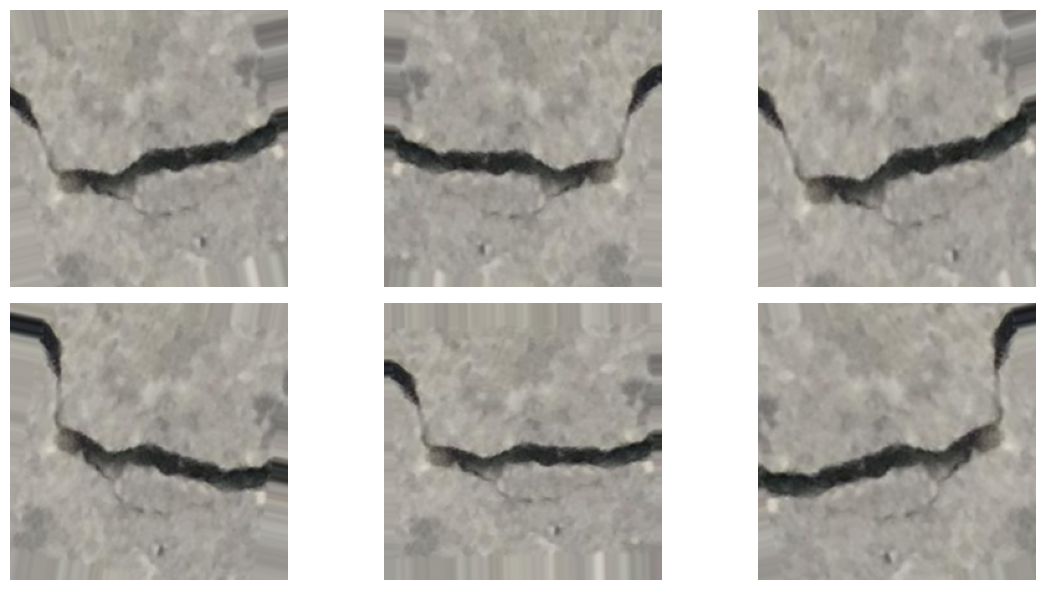

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Same augmentation you used during training
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

sample_image_path = os.path.join("Positive", random.choice(os.listdir("Positive")))
img = Image.open(sample_image_path).resize((224,224))
img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=0)

plt.figure(figsize=(12,6))

for i, batch in enumerate(datagen.flow(img_array, batch_size=1)):
    plt.subplot(2,3,i+1)
    plt.imshow(batch[0])
    plt.axis("off")

    if i == 5:
        break

plt.tight_layout()
plt.show()

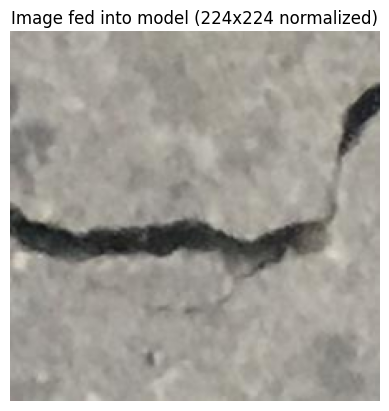

Shape: (224, 224, 3)
Min pixel value: 0.06274509803921569
Max pixel value: 0.8666666666666667


In [ ]:
img = Image.open(sample_image_path).resize((224,224))
img_array = np.array(img) / 255.0  # rescaling

plt.imshow(img_array)
plt.title("Image fed into model (224x224 normalized)")
plt.axis("off")
plt.show()

print("Shape:", img_array.shape)
print("Min pixel value:", img_array.min())
print("Max pixel value:", img_array.max())

In [ ]:
img = np.expand_dims(img_array, axis=0)
prediction = model.predict(img)

print("Prediction value:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Model Prediction: Crack (Positive)")
else:
    print("Model Prediction: No Crack (Negative)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Prediction value: 1.0
Model Prediction: Crack (Positive)


In [ ]:
loss, acc = model.evaluate(val_generator)
print("Validation Loss:", loss)
print("Validation Accuracy:", acc)

250/250 ━━━━━━━━━━━━━━━━━━━━ 98s 391ms/step - accuracy: 0.5044 - loss: -3802.4233
Validation Loss: -3807.998779296875
Validation Accuracy: 0.5


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_full_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(img, (224,224))
    normalized = resized / 255.0
    input_img = np.expand_dims(normalized, axis=0)

    prediction = model.predict(input_img)[0][0]

    plt.imshow(resized)
    plt.title(f"Prediction: {prediction:.4f}")
    plt.axis("off")
    plt.show()

    if prediction > 0.5:
        print("Crack Detected")
    else:
        print("No Crack")

# Example
predict_full_image("your_full_image.jpg")

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
def split_into_patches(image, patch_size=224):
    patches = []
    h, w, _ = image.shape

    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            patch = image[y:y+patch_size, x:x+patch_size]

            if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
                patches.append((patch, x, y))

    return patches

In [ ]:
def predict_large_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    patches = split_into_patches(img)

    crack_found = False

    for patch, x, y in patches:
        normalized = patch / 255.0
        input_img = np.expand_dims(normalized, axis=0)

        prediction = model.predict(input_img)[0][0]

        if prediction > 0.5:
            crack_found = True
            cv2.rectangle(img, (x,y), (x+224,y+224), (255,0,0), 3)

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.title("Detected Crack Areas (Red Boxes)")
    plt.axis("off")
    plt.show()

    if crack_found:
        print("Crack detected in at least one patch.")
    else:
        print("No crack detected in any patch.")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving road_crack.jpg to road_crack.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


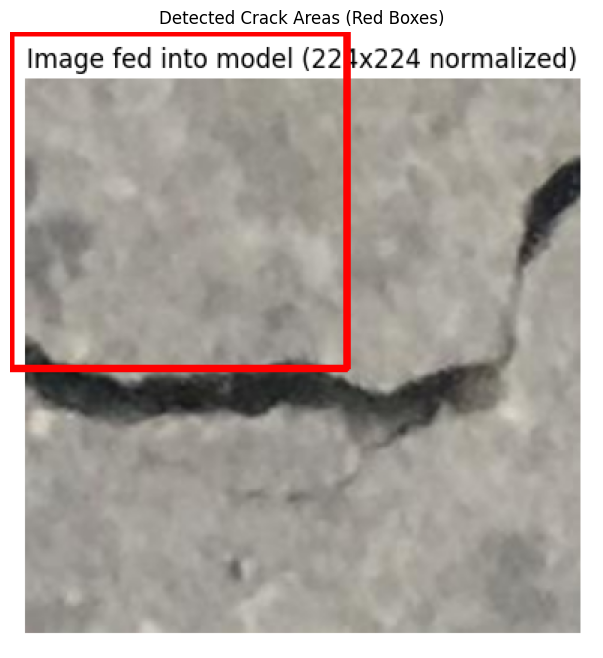

Crack detected in at least one patch.


In [ ]:
predict_large_image("road_crack.jpg")